In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d, RectBivariateSpline, splrep


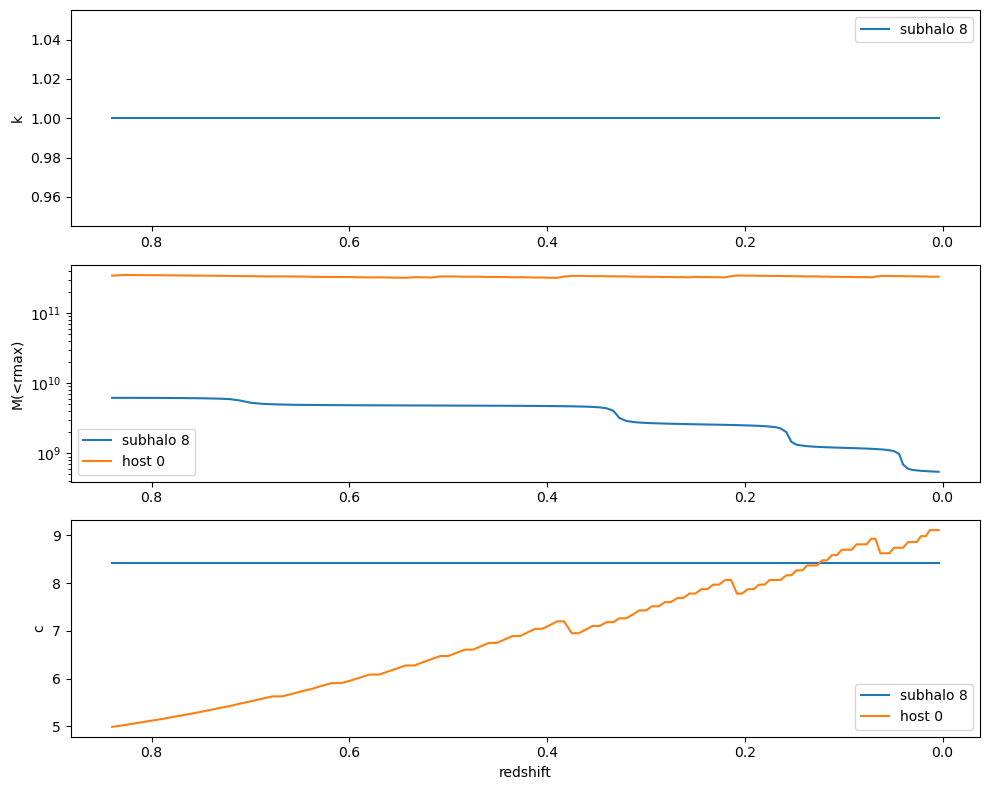

In [33]:

# read the log file
df = pd.read_csv('../../../StellarHalo/data/local_trees/low_res/test/tree_0_potential_test.txt', 
                  skiprows=2,  # skip header and separator line
                  sep='\s+', 
                  names=['z', 'id', 'order', 'parent', 'Mrmax_sub', 'Mrmax_host', 
                         'log10ch_sub', 'log10ch_host'])

# filter to a single subhalo
sub_id = 8#22 #28
sub = df[df['id'] == sub_id].sort_values('z', ascending=False)

# plot
fig, ax = plt.subplots(3, 1, figsize=(10, 8))

# Mass plot
ax[0].plot(sub['z'], sub['order'], label=f'subhalo {sub_id}')
ax[0].set_ylabel('k')
ax[0].invert_xaxis()  # z decreasing left to right
ax[0].legend()

# Mass plot
ax[1].plot(sub['z'], sub['Mrmax_sub'], label=f'subhalo {sub_id}')
ax[1].plot(sub['z'], sub['Mrmax_host'], label=f'host {sub["parent"].iloc[0]}')
ax[1].set_ylabel('M(<rmax)')
ax[1].set_yscale("log")
ax[1].invert_xaxis()  # z decreasing left to right
ax[1].legend()

# Concentration plot
ax[2].plot(sub['z'], sub['log10ch_sub'], label=f'subhalo {sub_id}')
ax[2].plot(sub['z'], sub['log10ch_host'], label=f'host {sub["parent"].iloc[0]}')
ax[2].set_xlabel('redshift')
ax[2].set_ylabel('c')
ax[2].invert_xaxis()  # z decreasing left to right
ax[2].legend()

plt.tight_layout()
plt.show()

In [28]:
df

,z,id,order,parent,Mrmax_sub,Mrmax_host,log10ch_sub,log10ch_host
0,4.408,19,1,0,6.298000e+09,1.083000e+10,4.177,4.118
1,4.350,19,1,0,6.291000e+09,1.079000e+10,4.177,4.136
2,4.293,19,1,0,6.278000e+09,1.851000e+10,4.177,4.136
3,4.236,19,1,0,6.240000e+09,1.880000e+10,4.177,4.056
4,4.181,19,1,0,6.189000e+09,1.880000e+10,4.177,4.056
...,...,...,...,...,...,...,...,...
3818,0.004,24,2,16,3.124000e+06,1.300000e+07,4.048,4.058
3819,0.004,25,2,16,2.852000e+06,1.300000e+07,4.102,4.058
3820,0.004,26,2,17,1.705000e+06,8.995000e+06,4.814,4.157
3821,0.004,27,2,17,2.751000e+06,8.995000e+06,4.052,4.157


In [6]:
tree = np.load('../../../StellarHalo/data/local_trees/low_res/test/tree_0.npz')

In [20]:
c_arr = tree["concentration"]

masked_arr = np.where(c_arr == -99, np.nan, c_arr)

acc_index = np.argmax(tree["mass"], axis=1)

acc_order = tree["order"][np.arange(acc_index.shape[0]), acc_index]

In [21]:
ntimesteps_withc = np.sum(~np.isnan(masked_arr), axis=1)

(0.0, 4.0)

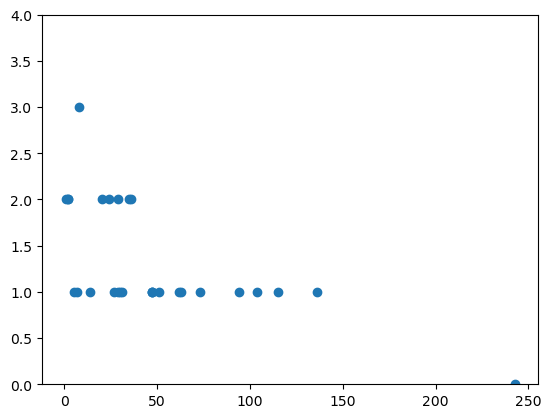

In [25]:
plt.scatter(ntimesteps_withc, acc_order)
plt.ylim(0, 4)

In [4]:

gvdb_mm = np.load('/Users/jsmonzon/Research/SatGen/etc/gvdb_mm.npy')
gvdb_sm = np.load('/Users/jsmonzon/Research/SatGen/etc/gvdb_sm.npy')
gvdb_pm = np.load('/Users/jsmonzon/Research/SatGen/etc/gvdb_pm.npy')

nfb = 100
nr = 131
ncs = 30
fb_vals_int = np.logspace(-5, 0, nfb)
# NOTE: This approach implicitly assumes that DASH concentrations correspond
# to virial concentrations, and hence that DASH truncates at the BN98 virial
# radius.
r_vals_int = np.logspace(-5.5, 1., nr)
cs_vals_int = np.logspace(0, np.log10(40), ncs)
fbv_min = np.min(fb_vals_int) # Same as phi_{res} in paper; fiducial of 10^-5
fbv_max = np.max(fb_vals_int)
rv_min = np.min(r_vals_int)
rv_max = np.max(r_vals_int)
csv_min = np.min(cs_vals_int)
csv_max = np.max(cs_vals_int)
log_fb_vals_int = np.log10(fb_vals_int)
log_r_vals_int = np.log10(r_vals_int)
log_cs_vals_int = np.log10(cs_vals_int)
fb_cs_interps_mass = []
fb_cs_interps_sigma = []
fb_cs_interps_d2Phidr2 = []
# TODO: Decide if switching to linear-space from log-space gives
# a speed-up sufficiently worth it..?
for i in range(0, nr):
    fb_cs_interps_mass.append(RectBivariateSpline(log_fb_vals_int,
                                                  log_cs_vals_int,
                                                  gvdb_mm[:,:,i]))

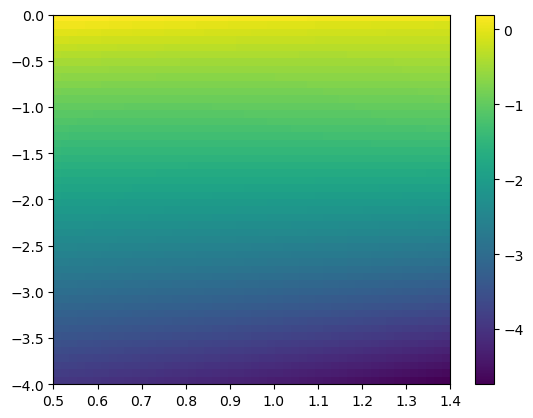

In [5]:
rad_index = -16

logcs_vals = np.linspace(0.5, 1.4)
logfb_vals = np.linspace(-4, 0,)

image = fb_cs_interps_mass[rad_index](logfb_vals, logcs_vals)

fig, ax = plt.subplots()

im = ax.imshow(
    np.log10(image),
    origin="lower",
    extent=[logcs_vals.min(), logcs_vals.max(),
            logfb_vals.min(), logfb_vals.max()],
    aspect="auto"
)

fig.colorbar(im, ax=ax)